## 1. Kiểm định tiền xử lý và trích xuất nhân tố (PCA DIAGNOSTICS)

Áp dụng cho việc tổng hợp **Chỉ số Bao trùm tài chính ($FI$)** từ 4 biến (`BANK, ATM, DEP, LOAN`) và **Chỉ số Fintech ($FT$)** từ 3 biến (`FT_Mobile, FT_Broadband, FT_Internet`).
### 1.1. Kiểm định Kaiser-Meyer-Olkin
Đánh giá mức độ tương quan riêng giữa các biến để xem tập dữ liệu có đủ điều kiện để phân tích PCA không 

In [1]:
!pip install factor-analyzer

  Using cached factor_analyzer-0.5.1-py2.py3-none-any.whl



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import numpy as np
import pandas as pd
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [9]:
df = pd.read_csv('data/master_dataset_clean.csv')

for col in ['BANK', 'ATM', 'DEP', 'LOAN', 'FT_Mobile', 'FT_Broadband', 'FT_Internet']:
    df[f'ln_{col}'] = np.log(df[col] + 1e-4)

df[[c for c in df.columns if 'ln' in c]]

,ln_BANK,ln_ATM,ln_DEP,ln_LOAN,ln_FT_Mobile,ln_FT_Broadband,ln_FT_Internet
0,3.284508,4.428518,23.161632,22.631885,4.396332,3.413115,4.394450
1,3.326803,4.468261,23.161632,22.631885,4.426312,3.500190,4.394450
2,3.333875,4.494747,23.161632,22.631885,4.420296,3.555838,4.415221
3,3.342725,4.521390,23.161632,22.631885,4.442904,3.607761,4.435569
4,3.365349,4.551412,23.161632,22.631885,4.497966,3.664001,4.455511
...,...,...,...,...,...,...,...
2185,1.101716,2.257122,3.454126,2.471064,4.607520,-0.839336,2.684160
2186,1.008833,2.128904,3.240498,2.247642,4.637470,-0.888656,2.696113
2187,0.979764,2.078351,3.393300,2.362653,4.589420,-0.846182,2.708057
2188,0.956320,2.123827,3.465790,2.544955,4.625577,-0.383474,2.800374


In [15]:
def interpret_kmo(kmo_val):
    if kmo_val >= 0.8:
        return 'Rất tốt (Meritorious)'
    elif kmo_val >= 0.7:
        return 'Tốt (Middling)'
    elif kmo_val >= 0.6:
        return 'Tạm chấp nhận (Mediocre)'
    elif kmo_val >= 0.5:
        return 'Tối thiểu đạt yêu cầu (Miserable)'
    else:
        return 'Không đạt điều kiện chạy PCA (Unacceptable)'

fi_vars = ['BANK', 'ATM', 'DEP', 'LOAN']
ft_vars = [ 'FT_Mobile', 'FT_Broadband', 'FT_Internet']

fi_data = df[fi_vars].dropna()
ft_data = df[ft_vars].dropna()
kmo_per_var_fi, kmo_total_fi = calculate_kmo(fi_data)
kmo_per_var_ft, kmo_total_ft = calculate_kmo(ft_data)
print('=' * 60)
print('KẾT QUẢ KIỂM ĐỊNH KMO CHO NHÓM BAO TRÙM TÀI CHÍNH (FI)')
print('=' * 60)
for var, val in zip(fi_vars, kmo_per_var_fi):
    print(f'• KMO riêng của biến {var:<15}: {val:.4f}')
print(f'-> KMO TỔNG THỂ (Overall KMO)    : {kmo_total_fi:.4f}')
print(f'-> Đánh giá học thuật            : {interpret_kmo(kmo_total_fi)}\n')


print('=' * 60)
print('📊 KẾT QUẢ KIỂM ĐỊNH KMO CHO NHÓM FINTECH (FT)')
print('=' * 60)
for var, val in zip(ft_vars, kmo_per_var_ft):
    print(f'• KMO riêng của biến {var:<15}: {val:.4f}')
print(f'-> KMO TỔNG THỂ (Overall KMO)    : {kmo_total_ft:.4f}')
print(f'-> Đánh giá học thuật            : {interpret_kmo(kmo_total_ft)}')
print('=' * 60)

KẾT QUẢ KIỂM ĐỊNH KMO CHO NHÓM BAO TRÙM TÀI CHÍNH (FI)
• KMO riêng của biến BANK           : 0.5001
• KMO riêng của biến ATM            : 0.5004
• KMO riêng của biến DEP            : 0.5000
• KMO riêng của biến LOAN           : 0.5000
-> KMO TỔNG THỂ (Overall KMO)    : 0.5001
-> Đánh giá học thuật            : Tối thiểu đạt yêu cầu (Miserable)

📊 KẾT QUẢ KIỂM ĐỊNH KMO CHO NHÓM FINTECH (FT)
• KMO riêng của biến FT_Mobile      : 0.7039
• KMO riêng của biến FT_Broadband   : 0.5890
• KMO riêng của biến FT_Internet    : 0.5600
-> KMO TỔNG THỂ (Overall KMO)    : 0.5982
-> Đánh giá học thuật            : Tối thiểu đạt yêu cầu (Miserable)


### 1.2.  Kiểm định Bartlett's Test of Sphericity
Kiểm tra xem các biến có tương quan đáng kể với nhau hay không.

* $H_0$: Ma trận tương quan giữa các biến là ma trận đơn vị ($I$) (nghĩa là các biến độc lập tuyến tính hoàn toàn, không có tương quan).
* $H_1$: Ma trận tương quan khác ma trận đơn vị (tồn tại tương quan tuyến tính giữa các biến).

In [17]:
chi_sq_fi, p_val_fi = calculate_bartlett_sphericity(fi_data)
chi_sq_ft, p_val_ft = calculate_bartlett_sphericity(ft_data)

print('=' * 65)
print("📊 KIỂM ĐỊNH BARTLETT'S TEST: NHÓM BAO TRÙM TÀI CHÍNH (FI)")
print('=' * 65)
print(f'• Giá trị Chi bình phương (Chi-Square) : {chi_sq_fi:.4f}')
print(f'• Mức ý nghĩa thống kê (p-value)       : {p_val_fi:.4e}')
if p_val_fi < 0.05:
    print(
        '-> KẾT LUẬN: Bác bỏ H0 (p < 0.05). Các biến tài chính có tương quan ý nghĩa, ĐỦ ĐIỀU KIỆN CHẠY PCA!'
    )
else:
    print('-> KẾT LUẬN: Không bác bỏ H0. Không đủ điều kiện chạy PCA.')
print('=' * 65)


print("\n📊 KIỂM ĐỊNH BARTLETT'S TEST: NHÓM CÔNG NGHỆ TÀI CHÍNH (FT)")
print('=' * 65)
print(f'• Giá trị Chi bình phương (Chi-Square) : {chi_sq_ft:.4f}')
print(f'• Mức ý nghĩa thống kê (p-value)       : {p_val_ft:.4e}')
if p_val_ft < 0.05:
    print(
        '-> KẾT LUẬN: Bác bỏ H0 (p < 0.05). Các biến Fintech có tương quan ý nghĩa, ĐỦ ĐIỀU KIỆN CHẠY PCA!'
    )
else:
    print('-> KẾT LUẬN: Không bác bỏ H0. Không đủ điều kiện chạy PCA.')
print('=' * 65)

📊 KIỂM ĐỊNH BARTLETT'S TEST: NHÓM BAO TRÙM TÀI CHÍNH (FI)
• Giá trị Chi bình phương (Chi-Square) : 10934.6091
• Mức ý nghĩa thống kê (p-value)       : 0.0000e+00
-> KẾT LUẬN: Bác bỏ H0 (p < 0.05). Các biến tài chính có tương quan ý nghĩa, ĐỦ ĐIỀU KIỆN CHẠY PCA!

📊 KIỂM ĐỊNH BARTLETT'S TEST: NHÓM CÔNG NGHỆ TÀI CHÍNH (FT)
• Giá trị Chi bình phương (Chi-Square) : 3253.9825
• Mức ý nghĩa thống kê (p-value)       : 0.0000e+00
-> KẾT LUẬN: Bác bỏ H0 (p < 0.05). Các biến Fintech có tương quan ý nghĩa, ĐỦ ĐIỀU KIỆN CHẠY PCA!


### 1.3. Tiêu chuẩn Eigenvalue (Kaiser Criterion) & Scree Plot
Xác định số lượng thành phần chính cần giữ lại.

Giữ lại các thành phần chính ($PC$) có $\text{Eigenvalue} (\lambda) \ge 1$.

In [ ]:
scaler = StandardScaler()

X_fi = fi_data
X_fi_scaled = scaler.fit_transform(X_fi)

pca_fi_full = PCA(n_components=len(fi_vars))
pca_fi_full.fit(X_fi_scaled)

eigenvalues_fi = pca_fi_full.explained_variance_
var_ratio_fi = pca_fi_full.explained_variance_ratio_ * 100
cum_var_fi = np.cumsum(var_ratio_fi)
print('=' * 75)
print('📊 1. KẾT QUẢ EIGENVALUES & PHƯƠNG SAI GIẢI THÍCH: NHÓM FI')
print('=' * 75)
fi_summary_table = pd.DataFrame({
    'Thành phần (Component)': [f'PC{i+1}' for i in range(len(fi_vars))],
    'Eigenvalue (λ)': eigenvalues_fi.round(4),
    'Phương sai giải thích (%)': var_ratio_fi.round(2),
    'Phương sai tích lũy (%)': cum_var_fi.round(2),
})
display(fi_summary_table)

pca_fi_2 = PCA(n_components=2)
fi_pcs = pca_fi_2.fit_transform(X_fi_scaled)

pc1_fi = fi_pcs[:, 0]
pc2_fi = fi_pcs[:, 1]
if pca_fi_2.components_[0].sum() < 0:
    pc1_fi = -pc1_fi
if pca_fi_2.components_[1].sum() < 0:
    pc2_fi = -pc2_fi
w1 = pca_fi_2.explained_variance_[0]
w2 = pca_fi_2.explained_variance_[1]
df['FI'] = (w1 * pc1_fi + w2 * pc2_fi) / (w1 + w2)

df['FI_x_FT'] = df['FI'] * df['FT']


print('=' * 65)
print('🎉 HOÀN THÀNH TOÀN BỘ GIAI ĐOẠN PCA!')
print('=' * 65)
print(f'• Đã tạo cột FI (Chỉ số Bao trùm tài chính toàn diện - 86.81% thông tin)')
print(f'• Đã tạo cột FT (Chỉ số Fintech - 74.45% thông tin)')
print(f'• Đã tạo cột FI_x_FT (Biến tương tác điều tiết)')
print(f'• Đã lưu file kết quả vào: {output_path}')

X_ft = ft_data
X_ft_scaled = scaler.fit_transform(X_ft)

pca_ft_full = PCA(n_components=len(ft_vars))
pca_ft_full.fit(X_ft_scaled)

eigenvalues_ft = pca_ft_full.explained_variance_
var_ratio_ft = pca_ft_full.explained_variance_ratio_ * 100
cum_var_ft = np.cumsum(var_ratio_ft)

print('\n' + '=' * 75)
print('📊 2. KẾT QUẢ EIGENVALUES & PHƯƠNG SAI GIẢI THÍCH: NHÓM FT')
print('=' * 75)
ft_summary_table = pd.DataFrame({
    'Thành phần (Component)': [f'PC{i+1}' for i in range(len(ft_vars))],
    'Eigenvalue (λ)': eigenvalues_ft.round(4),
    'Phương sai giải thích (%)': var_ratio_ft.round(2),
    'Phương sai tích lũy (%)': cum_var_ft.round(2),
})
display(ft_summary_table)

# Trích xuất PC1 cho FT
pca_ft_1 = PCA(n_components=1)
ft_score = pca_ft_1.fit_transform(X_ft_scaled)

loadings_ft = pca_ft_1.components_[0]
if loadings_ft.sum() < 0:
    ft_score = -ft_score
    loadings_ft = -loadings_ft

df['FT'] = ft_score
print('-> Factor Loadings (Trọng số của từng biến vào FT):')
for var, load in zip(ft_vars, loadings_ft):
    print(f'   • {var:<18}: {load:.4f}')
display(df[['country_code', 'country', 'year', 'FI', 'FT', 'FI_x_FT']].head(10))
output_path = 'data/master_dataset_with_pca.csv'
df.to_csv(output_path, index=False, encoding='utf-8')

📊 1. KẾT QUẢ EIGENVALUES & PHƯƠNG SAI GIẢI THÍCH: NHÓM FI


,Thành phần (Component),Eigenvalue (λ),Phương sai giải thích (%),Phương sai tích lũy (%)
0,PC1,1.9972,49.91,49.91
1,PC2,1.4770,36.91,86.81
2,PC3,0.5233,13.08,99.89
3,PC4,0.0044,0.11,100.00


🎉 HOÀN THÀNH TOÀN BỘ GIAI ĐOẠN PCA!
• Đã tạo cột FI (Chỉ số Bao trùm tài chính toàn diện - 86.81% thông tin)
• Đã tạo cột FT (Chỉ số Fintech - 74.45% thông tin)
• Đã tạo cột FI_x_FT (Biến tương tác điều tiết)
• Đã lưu file kết quả vào: data/master_dataset_with_pca.csv

📊 2. KẾT QUẢ EIGENVALUES & PHƯƠNG SAI GIẢI THÍCH: NHÓM FT


,Thành phần (Component),Eigenvalue (λ),Phương sai giải thích (%),Phương sai tích lũy (%)
0,PC1,2.2346,74.45,74.45
1,PC2,0.5973,19.90,94.35
2,PC3,0.1695,5.65,100.00


-> Factor Loadings (Trọng số của từng biến vào FT):
   • FT_Mobile         : 0.5092
   • FT_Broadband      : 0.5875
   • FT_Internet       : 0.6289


,country_code,country,year,FI,FT,FI_x_FT
0,AND,Andorra,2010,0.357234,0.748364,0.267341
1,AND,Andorra,2011,0.401244,0.891955,0.357892
2,AND,Andorra,2012,0.419614,0.997052,0.418377
3,AND,Andorra,2013,0.439494,1.133058,0.497971
4,AND,Andorra,2014,0.469714,1.318662,0.619393
5,AND,Andorra,2015,0.524374,1.617496,0.848172
6,AND,Andorra,2016,0.560385,1.843569,1.033108
7,AND,Andorra,2017,0.581521,1.987647,1.155859
8,AND,Andorra,2018,0.589631,2.080658,1.226821
9,AND,Andorra,2019,0.618820,2.093010,1.295197


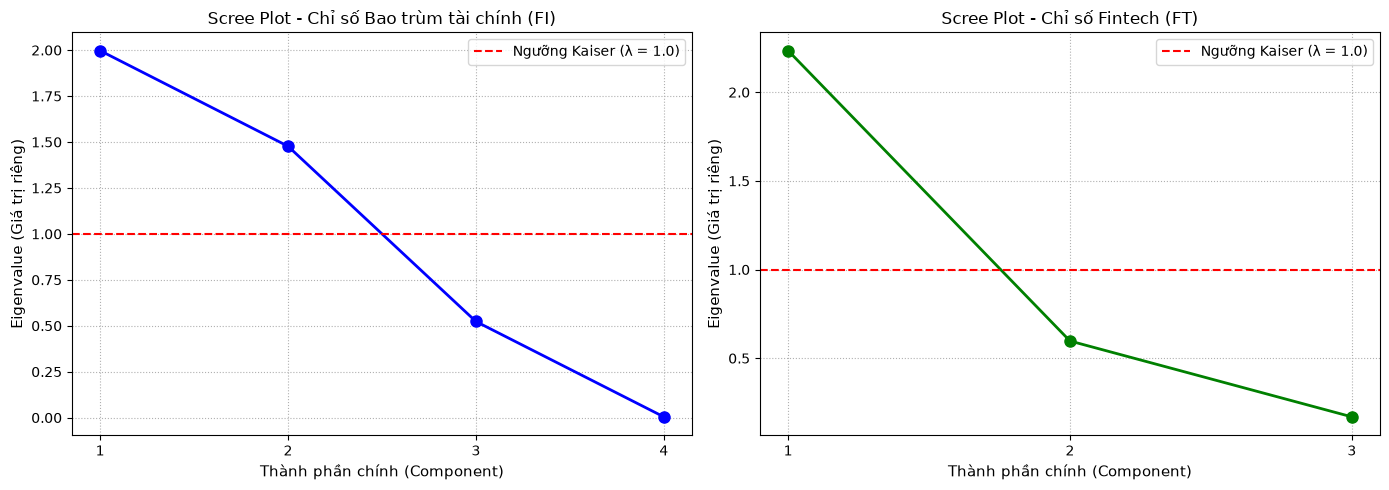

In [25]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot cho FI
axes[0].plot(
    range(1, len(fi_vars) + 1),
    eigenvalues_fi,
    'bo-',
    linewidth=2,
    markersize=8,
)
axes[0].axhline(
    y=1.0, color='r', linestyle='--', label='Ngưỡng Kaiser (λ = 1.0)'
)
axes[0].set_title('Scree Plot - Chỉ số Bao trùm tài chính (FI)', fontsize=12)
axes[0].set_xlabel('Thành phần chính (Component)', fontsize=11)
axes[0].set_ylabel('Eigenvalue (Giá trị riêng)', fontsize=11)
axes[0].set_xticks(range(1, len(fi_vars) + 1))
axes[0].legend()
axes[0].grid(True, linestyle=':')

# Scree plot cho FT
axes[1].plot(
    range(1, len(ft_vars) + 1),
    eigenvalues_ft,
    'go-',
    linewidth=2,
    markersize=8,
)
axes[1].axhline(
    y=1.0, color='r', linestyle='--', label='Ngưỡng Kaiser (λ = 1.0)'
)
axes[1].set_title('Scree Plot - Chỉ số Fintech (FT)', fontsize=12)
axes[1].set_xlabel('Thành phần chính (Component)', fontsize=11)
axes[1].set_ylabel('Eigenvalue (Giá trị riêng)', fontsize=11)
axes[1].set_xticks(range(1, len(ft_vars) + 1))
axes[1].legend()
axes[1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()